In [7]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import os, pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import hist
import vector
import pandas as pd

from physics.simulation import msq, mcfm
from physics.hstar import c6
from datasets import coefficient
from models import taylr

import torch
from torch.utils.data import DataLoader
import lightning as L

torch.set_float32_matmul_precision('high')

In [ ]:
RUN_DIR = 'run'
TAYLR_DIR = 'taylr'

CHECKPOINTS = [ '181' ]
LOSSES = ['0.00', '0.25', '0.12', '0.15']
VERSIONS = ['0', '0', '0', '0']

EVENTS = 'events.pkl'
SCALER = 'scaler.pkl'

ncoeffs = len(CHECKPOINTS)

EVENTS_PATHS = [os.path.join(RUN_DIR, TAYLR_DIR+f'_{i+1}', EVENTS) for i  in range(ncoeffs)]
SCALER_PATHS = [os.path.join(RUN_DIR, TAYLR_DIR+f'_{i+1}', SCALER) for i in range(ncoeffs)]

CHECKPOINT_PATHS = [os.path.join(RUN_DIR, TAYLR_DIR+f'_{i+1}', 'checkpoints', f'checkpoint-taylr-epoch={CHECKPOINTS[i]}-val_loss={LOSSES[i]}.ckpt') for i in range(ncoeffs)]
METRICS_PATHS = [os.path.join(RUN_DIR, TAYLR_DIR+f'_{i+1}', 'lightning_logs', f'version_{VERSIONS[i]}', 'metrics.csv') for i in range(ncoeffs)]

In [9]:
SAMPLE_SIZE = 1200000
BATCH_SIZE = 128
SEED = 42
FEATURES = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy', 'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy', 'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy', 'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

In [10]:
with open(EVENTS_PATHS[0], 'rb') as f:
    events = pickle.load(f)
# events_train, events_val, events_test = events.sample(SAMPLE_SIZE,random_state=SEED).split(train_size=1.0, val_size=0.1, test_size=0.1)
events_train, events_val, events_test = events.split(train_size=1.0, val_size=0.1, test_size=0.1)

print(events_test.kinematics.shape[0] / events.kinematics.shape[0])
print(events_val.kinematics.shape[0] / events.kinematics.shape[0])
print(events_train.kinematics.shape[0] / events.kinematics.shape[0])

0.013889122960765807
0.013888771852950428
0.8333333333333334


In [11]:
validation_datasets = [coefficient.CoefficientDataset(events_val, features=FEATURES, coefficient_index=i+1, component=msq.Component.SBI) for i in range(ncoeffs)]
testing_datasets = [coefficient.CoefficientDataset(events_test, features=FEATURES, coefficient_index=i+1, component=msq.Component.SBI) for i in range(ncoeffs)]

for i in range(ncoeffs):
    with open(SCALER_PATHS[i], 'rb') as f:
        scaler = pickle.load(f)
    validation_datasets[i].X = scaler.transform(validation_datasets[i].X)
    testing_datasets[i].X = scaler.transform(testing_datasets[i].X)

In [12]:
metrics = [np.genfromtxt(path, delimiter=',') for path in METRICS_PATHS]

epochs = [m[1::2,0] for m in metrics]
steps = [m[1::2,1] for m in metrics]
train_loss = [m[0::2,2][1:] for m in metrics]
val_loss = [m[1::2,3] for m in metrics]

FileNotFoundError: run/taylr_1/lightning_logs/version_3/metrics.csv not found.

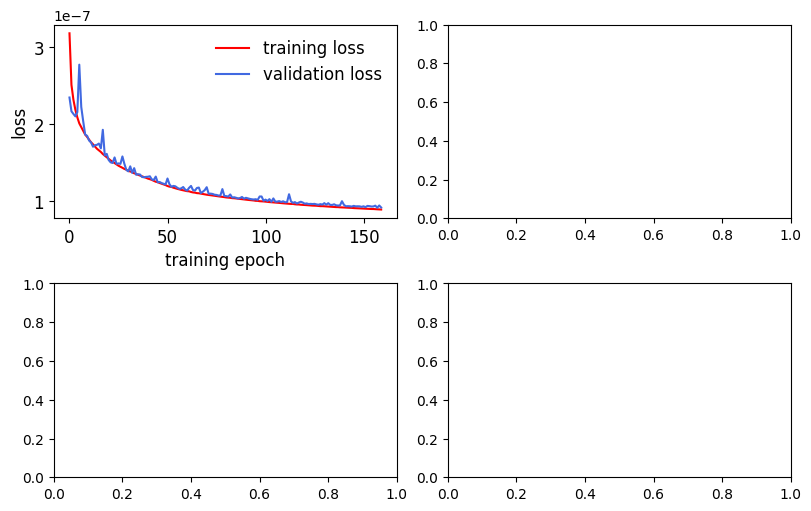

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(8,5), layout='constrained')

for i in range(ncoeffs):
    axes[i//2,i%2].plot(epochs[i], train_loss[i], color='red', label='training loss')
    axes[i//2,i%2].plot(epochs[i], val_loss[i], color='royalblue', label='validation loss')

    axes[i//2,i%2].legend(frameon=False, fontsize=12)
    axes[i//2,i%2].set_xlabel('training epoch', fontsize=12)
    axes[i//2,i%2].set_ylabel('loss', fontsize=12)
    axes[i//2,i%2].tick_params(axis='both', labelsize=12)

plt.show()

In [ ]:
models = [taylr.TAYLR.load_from_checkpoint(path) for path in CHECKPOINT_PATHS]

In [ ]:
validation_dataloaders = [DataLoader(val, BATCH_SIZE) for val in validation_datasets]
testing_dataloaders = [DataLoader(val, BATCH_SIZE) for val in testing_datasets]

In [ ]:
trainer = L.Trainer(accelerator='gpu')
pred_val = [torch.concatenate(trainer.predict(model, validation_dataloaders[i])).numpy()[:,np.newaxis].flatten() for i, model in enumerate(models)]
pred_test = [torch.concatenate(trainer.predict(model, testing_dataloaders[i])).numpy()[:,np.newaxis].flatten() for i, model in enumerate(models)]

target_test = [ds.y for ds in validation_datasets]
target_test = [ds.y for ds in testing_datasets]

Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting: |                                                                                                 …

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting: |                                                                                                 …

In [ ]:
def calibration_curve(axes, p, t, labels, bounds, bins, ylim):
    step_size = (bounds[1]-bounds[0])/bins

    targets_binned = [t[(p > bounds[0]+step_size*i) & (p <= bounds[0]+step_size*(i+1))] for i in range(bins)]

    targets_mean = np.array([np.mean(bin) for bin in targets_binned])
    targets_dev = np.array([np.std(bin) for bin in targets_binned])

    centers = np.array([bounds[0]+(i+1/2)*step_size for i in range(bins)])

    formatter_1 = ticker.ScalarFormatter(useMathText=True)
    formatter_1.set_scientific(True)
    formatter_1.set_powerlimits((-2,2))

    formatter_2 = ticker.ScalarFormatter(useMathText=True)
    formatter_2.set_scientific(True)
    formatter_2.set_powerlimits((-2,2))

    axes[0].set_xticklabels([])

    axes[0].yaxis.set_major_formatter(formatter_1)
    axes[1].yaxis.set_major_formatter(formatter_2)
    axes[1].xaxis.set_major_formatter(formatter_2)

    axes[0].errorbar(centers, centers, color='black', linestyle='--', label='targets')
    axes[0].errorbar(centers, targets_mean, yerr=targets_dev, color='royalblue', marker='o', markersize=4, linestyle='none', label='predictions', alpha=0.8)

    axes[0].set_xlim(*bounds)
    axes[0].set_ylim(*bounds)
    axes[0].set_ylabel(labels[0], fontsize=12)
    axes[0].tick_params(axis='both', labelsize=12)

    axes[0].legend(frameon=False, fontsize=12)

    axes[1].errorbar(centers, np.array(centers)-np.array(centers), color='black', linestyle='--', label='targets')
    axes[1].errorbar(centers, np.array(targets_mean)-np.array(centers), yerr=targets_dev, color='royalblue', marker='o', markersize=4, linestyle='none', label='predictions', alpha=0.8)

    axes[1].set_xlim(*bounds)
    axes[1].set_xlabel(labels[1], fontsize=12)
    axes[1].set_ylabel('Residual', fontsize=12)
    axes[1].set_ylim(*ylim)
    axes[1].tick_params(axis='both', labelsize=12)

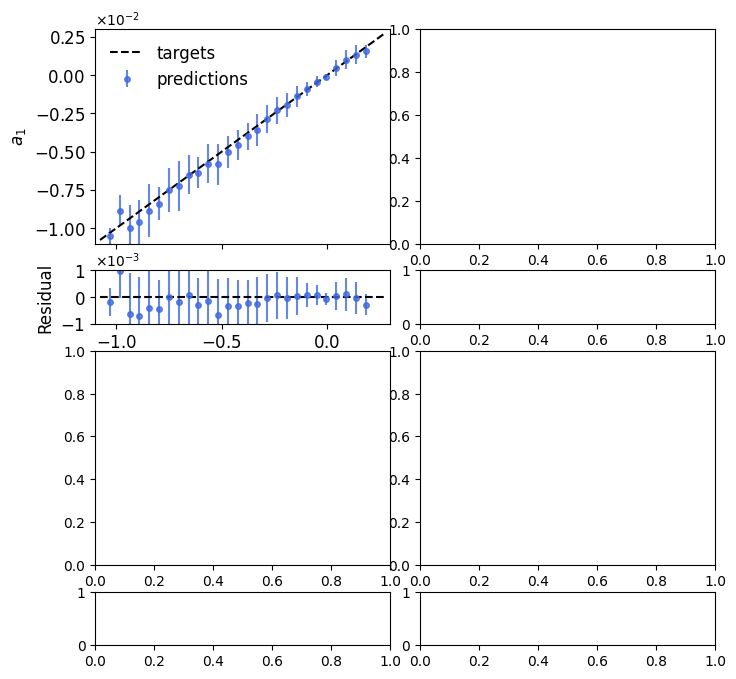

In [ ]:
BINS = 30
fig, axes = plt.subplots(4,2, gridspec_kw={'height_ratios': [4,1,4,1], 'wspace': 0.1}, figsize=(8,8))
calibration_curve(axes[:2,0], pred_test[0], target_test[0], ['$a_1$', '$\hat{{a}}_1$'], [-1.1e-2,3e-3], BINS, [-1e-3,1e-3])
# calibration_curve(axes[:2,1], pred_validation[1], validation_sets[1].y, ['$a_2$', '$\hat{{a}}_2$'], [-6e-4,1.2e-3], BINS, [-3e-4,3e-4])
# calibration_curve(axes[2:,0], pred_validation[2], validation_sets[2].y, ['$a_3$', '$\hat{{a}}_3$'], [-3.5e-5,1.2e-6], BINS, [-3e-6,3e-6])
# calibration_curve(axes[2:,1], pred_validation[3], validation_sets[3].y, ['$a_4$', '$\hat{{a}}_4$'], [-2e-7,3.6e-6], BINS, [-3e-7,3e-7])

In [ ]:
with open(SCALER_PATHS[0], 'rb') as f:
    scaler = pickle.load(f)
validation_data_unscaled = scaler.inverse_transform(testing_datasets[0].X)

l1 = vector.array({"pt": validation_data_unscaled[:,0], "eta": validation_data_unscaled[:,1], "phi": validation_data_unscaled[:,2], "energy": validation_data_unscaled[:,3]})
l2 = vector.array({"pt": validation_data_unscaled[:,4], "eta": validation_data_unscaled[:,5], "phi": validation_data_unscaled[:,6], "energy": validation_data_unscaled[:,7]})
l3 = vector.array({"pt": validation_data_unscaled[:,8], "eta": validation_data_unscaled[:,9], "phi": validation_data_unscaled[:,10], "energy": validation_data_unscaled[:,11]})
l4 = vector.array({"pt": validation_data_unscaled[:,12], "eta": validation_data_unscaled[:,13], "phi": validation_data_unscaled[:,14], "energy": validation_data_unscaled[:,15]})

m4l = (l1 + l2 + l3 + l4).mass

In [ ]:
c6_val = -10

c6mod = c6.Modifier(baseline=msq.Component.SBI, events=events_test, c6_values=[-5,-1,0,1,5])
c6_wt, c6_prob = c6mod.modify(c6_val)

c6_wt, c6_prob = c6_wt.flatten(), c6_prob.flatten()

In [ ]:
print(np.sum(c6_wt), np.sum(c6_prob))

0.16399189455107027 0.9999999999999999


In [ ]:
# coefficients = np.concatenate([np.ones(SAMPLE_SIZE)[:,np.newaxis], pred_test[0][:,np.newaxis], pred_test[1][:,np.newaxis], pred_test[2][:,np.newaxis], pred_test[3][:,np.newaxis]], axis=1)
coefficients = np.concatenate([np.ones(16667)[:,np.newaxis], pred_test[0][:,np.newaxis]], axis=1)
reweight = np.apply_along_axis(lambda x: np.polyval(x, c6_val), 1, coefficients[:, ::-1])

reweight /= np.sum(reweight)

In [ ]:
print(c6_prob)
print(reweight)
SAMPLE_SIZE = 16667

[7.04935077e-05 3.57022944e-05 5.89517745e-05 ... 4.17301272e-05
 6.77169074e-05 8.05154337e-05]
[5.99212816e-05 5.98627130e-05 5.98971523e-05 ... 5.98057607e-05
 5.99452169e-05 5.98365293e-05]


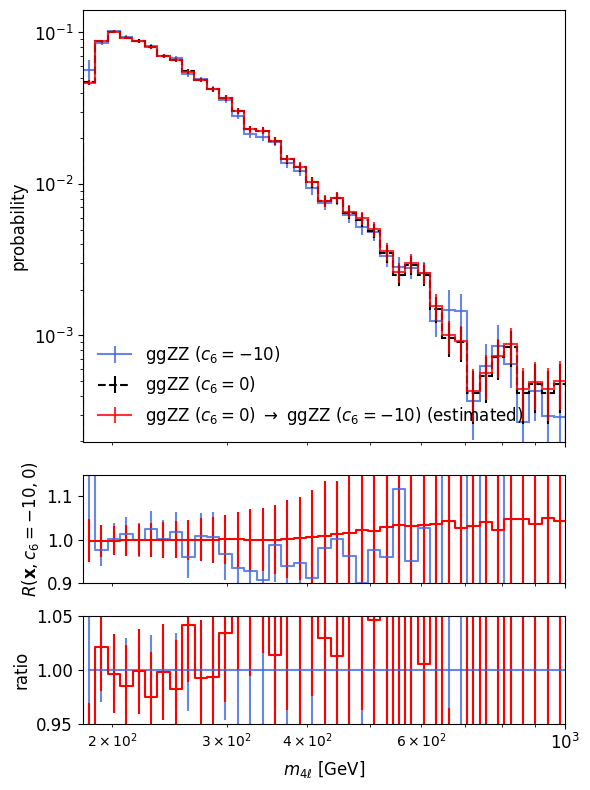

In [ ]:
bins = 40
bounds = [180,1050]

h_true = hist.Hist(hist.axis.Regular(bins, *bounds, transform=hist.axis.transform.log), storage=hist.storage.Weight())
h_true.fill(m4l, weight=np.ones(SAMPLE_SIZE)*c6_prob)

h_SM = hist.Hist(hist.axis.Regular(bins, *bounds, transform=hist.axis.transform.log), storage=hist.storage.Weight())
h_SM.fill(m4l, weight=np.ones(SAMPLE_SIZE)*1/SAMPLE_SIZE)


h_reweight = hist.Hist(hist.axis.Regular(bins, *bounds, transform=hist.axis.transform.log), storage=hist.storage.Weight())
h_reweight.fill(m4l, weight=np.ones(SAMPLE_SIZE)*reweight)

fig, (ax1, ax2, ax3) = plt.subplots(3,1,gridspec_kw={'height_ratios': [4, 1, 1]},figsize=(6,8), layout='constrained')

h_true.plot(ax=ax1,color='royalblue', label=f'ggZZ ($c_6 = {c6_val}$)', alpha=0.8)
h_SM.plot(ax=ax1,color='black', linestyle='--', label=f'ggZZ ($c_6 = 0$)')
h_reweight.plot(ax=ax1,color='red', label='ggZZ ($c_6 = 0$) $\\rightarrow$ ggZZ ($c_6=-10$) (estimated)', alpha=0.8)

ax1.set_xlabel('')
ax1.set_ylabel('probability', fontsize=12)
ax1.set_xlim(180,1000)
ax1.set_xscale('log')

ax1.set_xticklabels([])
ax1.tick_params(labelsize=12)
ax1.xaxis.set_tick_params(which='minor', labelleft=False, labelright=False)

ax1.set_yscale('log')
ax1.legend(frameon=False, fontsize=12)

ax2.errorbar(h_true.axes[0].centers, h_true.values()/h_SM.values(), yerr=np.sqrt((np.sqrt(h_true.variances())/h_SM.values())**2 + (-np.sqrt(h_SM.variances())*h_true.values()/h_SM.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'Truth qqZZ', alpha=0.8)
ax2.errorbar(h_reweight.axes[0].centers, h_reweight.values()/h_SM.values(), yerr=np.sqrt((np.sqrt(h_reweight.variances())/h_SM.values())**2 + (-np.sqrt(h_SM.variances())*h_reweight.values()/h_SM.values()**2)**2), color='r', drawstyle='steps-mid', label=f'CARL ggZZ->qqZZ')

ax2.tick_params(labelsize=12)

ax2.set_ylabel(f'$R(\mathbf{{x}}, c_6 = {c6_val},0)$', fontsize=12)
ax2.set_xlim(180,1000)
ax2.set_ylim(0.9,1.15)
ax2.set_xscale('log')
ax2.xaxis.set_tick_params(which='minor', labelleft=False, labelright=False)

ax2.set_xlabel('')
ax2.set_xticklabels([])

ax3.errorbar(h_true.axes[0].centers, h_true.values()/h_true.values(), yerr=np.sqrt(h_true.variances())/h_true.values(), color='royalblue', drawstyle='steps-mid', label=f'Truth qqZZ', alpha=0.8)
ax3.errorbar(h_reweight.axes[0].centers, h_reweight.values()/h_true.values(), yerr=np.sqrt((np.sqrt(h_reweight.variances())/h_true.values())**2 + (-np.sqrt(h_true.variances())*h_reweight.values()/h_true.values()**2)**2), color='r', drawstyle='steps-mid', label=f'CARL ggZZ->qqZZ')

ax3.tick_params(labelsize=12)

ax3.set_xlabel('$m_{4\ell}$ [GeV]', fontsize=12)
ax3.set_ylabel('ratio', fontsize=12)
ax3.set_xlim(180,1000)
ax3.set_ylim(0.95,1.05)
ax3.set_xscale('log')

plt.tight_layout()

plt.show()